# Deep learning in finance

## Deep Hedging — $n$-Dimensional Generalisation (Bonus)

Student name: *Romain ETIENNE* (as peer the first project, I am the only one who worked on this one)

This notebook generalises the deep hedging framework to an **arbitrary number $m$ of assets**. We demonstrate with $m = 5$.

**Key novelty compared to the 2D notebook:** rather than training $N$ separate neural networks (one per time step), we use a **single shared network** per delta component that takes the current **time $t_j$ as an additional input**. This significantly reduces the parameter count (from $N \times (\text{network size})$ to $1 \times (\text{network size})$), which is critical when $m$ and $N$ are both large.

**Payoff:** ATM geometric basket call
$$
g(\mathbf{S}_T) = \left(\exp\!\left(\frac{1}{m}\sum_{k=1}^m \log \frac{S^k_T}{S^k_0}\right) - 1\right)^+
$$
which has a **closed-form Black-Scholes price** (the geometric mean is log-normal), enabling a direct comparison.

In [1]:
import numpy as np
import tensorflow as tf

import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras

from keras.layers import Subtract, Multiply, Lambda, Add, Concatenate, Dense
from keras import initializers

import matplotlib.pyplot as plt
import scipy.stats as sps

I0000 00:00:1775146715.332025   27849 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Parameters

In [2]:
m   = 5      # number of assets — change this to scale up/down
N   = 30     # number of time steps (reduced for CPU feasibility; 100 gives better hedging precision)
T   = 1.0    # maturity (years)

S0_vec   = np.ones(m)              # initial prices (all 1 for simplicity)
mu_vec   = np.full(m, 0.02)        # drifts
sigma_vec = np.full(m, 0.20)       # volatilities
rho      = 0.3                     # uniform pairwise correlation
r        = 0.04                    # risk-free rate

# Correlation matrix: rho off-diagonal, 1 on diagonal
Sigma = rho * np.ones((m, m)) + (1 - rho) * np.eye(m)
L     = np.linalg.cholesky(Sigma)   # Cholesky factor

grid    = [(i / N) * T for i in range(N + 1)]
Delta_T = grid[1] - grid[0]

print("m = %d assets, N = %d steps, T = %.1f year" % (m, N, T))
print("rho = %.2f, r = %.2f" % (rho, r))

m = 5 assets, N = 30 steps, T = 1.0 year
rho = 0.30, r = 0.04


## Analytical benchmark: geometric basket call

The geometric basket $G_T = \exp\!\left(\frac{1}{m}\sum_k \log S^k_T\right)$ is log-normal under the risk-neutral measure with effective parameters:

$$
\sigma_{\text{eff}} = \frac{1}{m}\sqrt{\sum_{k,l} \sigma_k \sigma_l \rho_{kl}}, \qquad
\mu_{\text{eff}} = r - \frac{1}{2m}\sum_k \sigma_k^2 + \frac{1}{2}\sigma_{\text{eff}}^2
$$

so the price of the ATM call on $G_T / G_0$ follows the standard Black-Scholes formula.

In [3]:
def geometric_basket_call_price(S0_vec, sigma_vec, Sigma, r, T):
    """Closed-form price of an ATM call on the geometric basket G_T/G_0.
    Payoff: (G_T/G_0 - 1)^+ where G_T = exp(mean_k log S^k_T).
    """
    m_loc = len(sigma_vec)

    # Effective variance: (1/m^2) * sigma^T Sigma sigma  (element-wise sigma * Sigma * sigma)
    sigma_eff_sq = (1 / m_loc**2) * sigma_vec @ Sigma @ sigma_vec
    sigma_eff = np.sqrt(sigma_eff_sq)

    # Risk-neutral drift of log(G_T/G_0):
    # mean = (r - 0.5/m * sum sigma_k^2 + 0.5 * sigma_eff^2) * T
    drift = (r - 0.5 / m_loc * np.sum(sigma_vec**2) + 0.5 * sigma_eff_sq) * T

    # G_0 = exp(mean log S0) = 1 since all S0 = 1
    G_0 = np.exp(np.mean(np.log(S0_vec)))
    K   = G_0   # ATM strike

    # Black-Scholes formula for forward price F = G_0 * exp(drift)
    F = G_0 * np.exp(drift)
    d1 = (np.log(F / K) + 0.5 * sigma_eff_sq * T) / (sigma_eff * np.sqrt(T))
    d2 = d1 - sigma_eff * np.sqrt(T)

    price = np.exp(-r * T) * (F * sps.norm.cdf(d1) - K * sps.norm.cdf(d2))
    return price, sigma_eff

price_geom, sigma_eff = geometric_basket_call_price(S0_vec, sigma_vec, Sigma, r, T)
print("Geometric basket call price (closed form): %1.4f" % price_geom)
print("Effective volatility: %1.4f" % sigma_eff)

Geometric basket call price (closed form): 0.0668
Effective volatility: 0.1327


## Architecture: single NN with time as input

Instead of $N$ separate networks (one per time step), we use **one shared network** $h_\theta : \mathbb{R}^{m+1} \to \mathbb{R}^m$ that takes the concatenated input $(t_j, S^1_{t_j}, \ldots, S^m_{t_j})$ and outputs all $m$ delta components at once.

This reduces the parameter count from $\mathcal{O}(N \cdot n^2)$ to $\mathcal{O}(n^2)$, making the approach scalable to large $m$ and $N$.

We build the shared network **once** and call it at every time step in the loop.

In [4]:
# Shared hedging network architecture
d = 4    # number of layers (including output)
n = 64   # hidden width

# Build the shared network as a Keras Sequential model on a (1+m)-dimensional input
# Note: GlorotNormal (default) gives much better convergence than RandomNormal(0,1) for
# shared architectures where the same layers are applied N times in one forward pass.
shared_layers = []
for k in range(d):
    if k < d - 1:
        shared_layers.append(
            keras.layers.Dense(
                units=n,
                activation="tanh",
                trainable=True,
                kernel_initializer="glorot_normal",
                bias_initializer="zeros",
                name="shared_" + str(k),
            )
        )
    else:
        # Output: m delta values, linear activation
        shared_layers.append(
            keras.layers.Dense(
                units=m,
                activation="linear",
                trainable=True,
                kernel_initializer="glorot_normal",
                bias_initializer="zeros",
                name="shared_out",
            )
        )

## Training set — correlated $m$-asset GBM

In [5]:
N_train = 5 * 10**4  # reduced for CPU feasibility (increase to 10**5 for better convergence)

# Simulate correlated log-increments
log_increments = [
    mu_vec * Delta_T + sigma_vec * np.sqrt(Delta_T) * (np.random.normal(0, 1, (N_train, m)) @ L.T)
    for _ in range(N)
]  # each element: shape (N_train, m)

# For hedge_eval: vary asset 1 on a grid, fix all others at S0
S1_eval_grid = np.linspace(0.5, 1.5, N_train)
hedge_eval_train = np.tile(S0_vec, (N_train, 1)).copy()  # all at S0
hedge_eval_train[:, 0] = S1_eval_grid                    # vary S1

xtrain = (
    [np.tile(S0_vec, (N_train, 1))]     # initial prices: shape (N_train, m)
    + [np.zeros((N_train, 1))]          # scalar accumulated gain
    + [hedge_eval_train]                # delta-visualisation grid
    + [np.zeros((N_train, m))]          # premium input
    + log_increments                    # N log-increment arrays
)

ytrain = np.zeros((N_train, 1))

print("Training set: %d trajectories × %d assets × %d steps." % (N_train, m, N))

Training set: 50000 trajectories × 5 assets × 30 steps.


Let us plot sample trajectories for all $m$ assets:

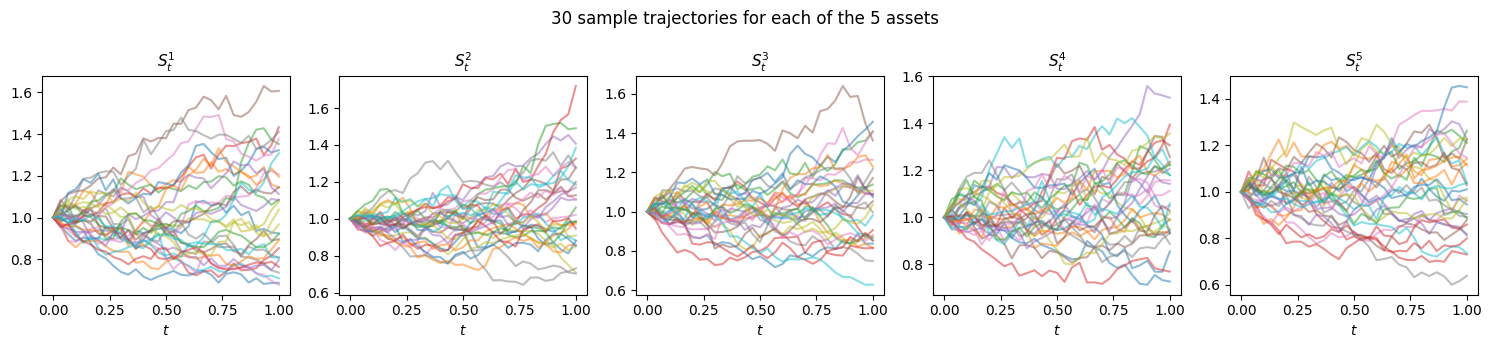

In [6]:
M_plot = 30
log_incr_arr = np.array(log_increments)  # shape (N, N_train, m)

fig, axes = plt.subplots(1, m, figsize=(3 * m, 3.5))
for k in range(m):
    log_Sk = np.cumsum(log_incr_arr[:, :M_plot, k], axis=0)  # shape (N, M_plot)
    traj_k = np.vstack([S0_vec[k] * np.ones((1, M_plot)), S0_vec[k] * np.exp(log_Sk)])
    axes[k].plot(grid, traj_k, alpha=0.5)
    axes[k].set_title(r"$S^{%d}_t$" % (k + 1), fontsize=11)
    axes[k].set_xlabel(r"$t$")

plt.suptitle("%d sample trajectories for each of the %d assets" % (M_plot, m), fontsize=12)
plt.tight_layout()
plt.show()

## Deep hedging model — shared time-input architecture

In [7]:
# ─── Inputs ───────────────────────────────────────────────────────────────────
price      = keras.Input(shape=(m,))   # price vector [S1,...,Sm]
hedge      = keras.Input(shape=(1,))   # scalar accumulated gain
hedge_eval = keras.Input(shape=(m,))   # [S1_grid, S2_0,...,Sm_0] for delta visualisation
premium_in = keras.Input(shape=(m,))   # zeros → learnable scalar premium

inputs      = [price, hedge, hedge_eval, premium_in]
output_helper = []

# ─── Learnable option premium ─────────────────────────────────────────────────
premium = keras.layers.Dense(
    units=1, activation="linear", trainable=True,
    kernel_initializer="glorot_normal",
    bias_initializer="zeros",
    name="premium"
)(premium_in)  # type: ignore

def apply_shared_network(x, name_prefix):
    """Apply the shared network layers to input x."""
    for layer in shared_layers:
        x = layer(x)
    return x

# ─── Time loop ────────────────────────────────────────────────────────────────
for j in range(N):
    # Concatenate (t_j, S_j) as input to the shared network
    t_j     = tf.constant(grid[j], dtype=tf.float32)
    t_j_vec = Lambda(
        lambda x, t=t_j: tf.fill([tf.shape(x)[0], 1], t),
        name="t_" + str(j)
    )(price)  # shape (batch, 1)
    t_j_eval = Lambda(
        lambda x, t=t_j: tf.fill([tf.shape(x)[0], 1], t),
        name="t_eval_" + str(j)
    )(hedge_eval)

    # Input for the shared network: [t_j, S^1,...,S^m]
    net_input      = Concatenate(name="input_" + str(j))([t_j_vec, price])
    net_input_eval = Concatenate(name="input_eval_" + str(j))([t_j_eval, hedge_eval])

    strategy      = net_input       # will hold h_theta(t_j, S_j): shape (batch, m)
    strategy_eval = net_input_eval

    for layer in shared_layers:
        strategy      = layer(strategy)
        strategy_eval = layer(strategy_eval)

    # ─ Log-increment input ───────────────────────────────────────────────────
    incr   = keras.Input(shape=(m,), name="incr_" + str(j))
    inputs = inputs + [incr]

    # ─ Price update ──────────────────────────────────────────────────────────
    logprice = Lambda(lambda x: tf.math.log(x), name="log_" + str(j))(price)
    logprice = Add(name="logadd_" + str(j))([logprice, incr])
    pricenew = Lambda(lambda x: tf.math.exp(x), name="exp_" + str(j))(logprice)
    priceincr = Subtract(name="dS_" + str(j))([pricenew, price])

    # ─ Portfolio dynamics with dot products ──────────────────────────────────
    portfolio_value = Add(name="V_" + str(j))([premium, hedge])

    delta_S_vec = Multiply(name="dSv_" + str(j))([strategy, price])
    delta_S     = Lambda(
        lambda x: tf.reduce_sum(x, axis=1, keepdims=True),
        name="dot_dS_" + str(j)
    )(delta_S_vec)

    cash_part = Subtract(name="cash_" + str(j))([portfolio_value, delta_S])
    interest  = Lambda(lambda x: r * Delta_T * x, name="int_" + str(j))(cash_part)

    delta_contrib_vec = Multiply(name="dcv_" + str(j))([strategy, priceincr])
    delta_contrib     = Lambda(
        lambda x: tf.reduce_sum(x, axis=1, keepdims=True),
        name="dot_dc_" + str(j)
    )(delta_contrib_vec)

    hedgenew = Add(name="dV_" + str(j))([interest, delta_contrib])
    hedge    = Add(name="hedge_" + str(j))([hedge, hedgenew])

    output_helper = output_helper + [strategy_eval]
    price = pricenew

# ─── Payoff: ATM geometric basket call ───────────────────────────────────────
# G_T/G_0 = exp(mean_k log(S^k_T/S^k_0)) = exp(mean_k log S^k_T) since S0=1
log_price_T   = Lambda(lambda x: tf.math.log(x), name="log_T")(price)
mean_log      = Lambda(
    lambda x: tf.reduce_mean(x, axis=1, keepdims=True),
    name="mean_log"
)(log_price_T)
geom_basket   = Lambda(lambda x: tf.math.exp(x), name="geo_basket")(mean_log)  # G_T/G_0
payoff        = Lambda(lambda x: tf.math.maximum(x - 1.0, 0.0), name="payoff")(geom_basket)

# ─── Final outputs ────────────────────────────────────────────────────────────
outputs_main = Add(name="VT")([premium, hedge])
outputs_main = Subtract(name="error")([outputs_main, payoff])

outputs = [outputs_main] + output_helper + [premium]
outputs = Concatenate(name="output")(outputs)

model_hedge_strat = keras.models.Model(inputs=inputs, outputs=outputs)
print("Model built (shared time-input NN). Output shape: (batch, %d)" % (1 + N * m + 1))

E0000 00:00:1775146718.137132   27849 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model built (shared time-input NN). Output shape: (batch, 152)


In [8]:
def custom_loss(y_true, y_pred):
    z = y_pred[:, 0] - y_true[:, 0]
    z = Lambda(lambda x: tf.math.square(x))(z)
    return tf.math.reduce_mean(z)

model_hedge_strat.compile(optimizer="adam", loss=custom_loss)

## Training

In [9]:
model_hedge_strat.fit(x=xtrain, y=ytrain, epochs=20, verbose=2, batch_size=256)  # type: ignore

(Keras batch progress omitted for export; fit uses verbose=2, predict uses verbose=0.)


In [10]:
model_output = model_hedge_strat.predict(xtrain, verbose=0)  # type: ignore

$\blacktriangleright$ Hedging error and learned premium:

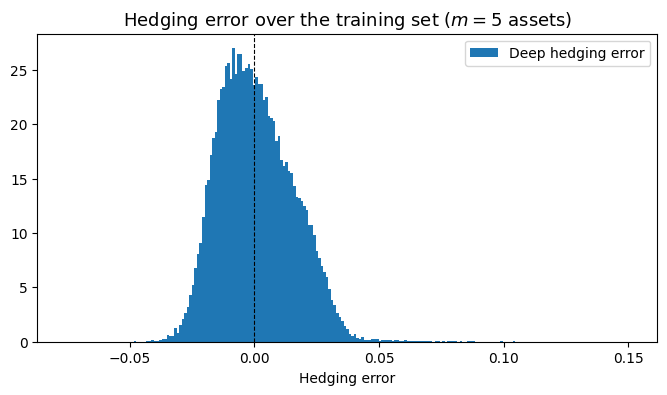

Closed-form geometric basket price      : 0.0668
Learned option premium π_0              : 0.0675

Hedging error (train) — mean : 6.8718e-04
Hedging error (train) — std  : 1.5030e-02


In [11]:
hedging_error_train = model_output[:, 0]  # type: ignore
learned_premium     = float(model_output[0, -1])  # type: ignore

plt.figure(figsize=(8, 4))
plt.hist(hedging_error_train, bins=int(np.sqrt(N_train)), density=True, label="Deep hedging error")
plt.axvline(0, linestyle='--', linewidth=0.8, color='k')
plt.title("Hedging error over the training set ($m = %d$ assets)" % m, fontsize=13)
plt.xlabel("Hedging error")
plt.legend(loc="best")
plt.show()

print("Closed-form geometric basket price      : %1.4f" % price_geom)
print("Learned option premium π_0              : %1.4f" % learned_premium)
print("")
print("Hedging error (train) — mean : %1.4e" % np.mean(hedging_error_train))
print("Hedging error (train) — std  : %1.4e" % np.std(hedging_error_train))

## Out-of-sample test set

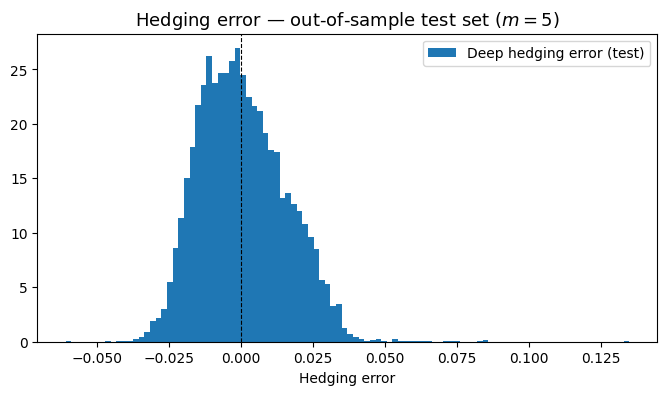

Hedging error (test) — mean : 5.8284e-04
Hedging error (test) — std  : 1.4962e-02


In [12]:
N_test_paths = 10**4

log_increments_test = [
    mu_vec * Delta_T + sigma_vec * np.sqrt(Delta_T) * (np.random.normal(0, 1, (N_test_paths, m)) @ L.T)
    for _ in range(N)
]

S1_eval_test_grid = np.linspace(0.5, 1.5, N_test_paths)
hedge_eval_test = np.tile(S0_vec, (N_test_paths, 1)).copy()
hedge_eval_test[:, 0] = S1_eval_test_grid

xtest = (
    [np.tile(S0_vec, (N_test_paths, 1))]
    + [np.zeros((N_test_paths, 1))]
    + [hedge_eval_test]
    + [np.zeros((N_test_paths, m))]
    + log_increments_test
)

model_output_test = model_hedge_strat.predict(xtest, verbose=0)  # type: ignore
hedging_error_test = model_output_test[:, 0]  # type: ignore

plt.figure(figsize=(8, 4))
plt.hist(hedging_error_test, bins=int(np.sqrt(N_test_paths)), density=True,
         label="Deep hedging error (test)")
plt.axvline(0, linestyle='--', linewidth=0.8, color='k')
plt.title("Hedging error — out-of-sample test set ($m = %d$)" % m, fontsize=13)
plt.xlabel("Hedging error")
plt.legend(loc="best")
plt.show()

print("Hedging error (test) — mean : %1.4e" % np.mean(hedging_error_test))
print("Hedging error (test) — std  : %1.4e" % np.std(hedging_error_test))

## Delta profiles

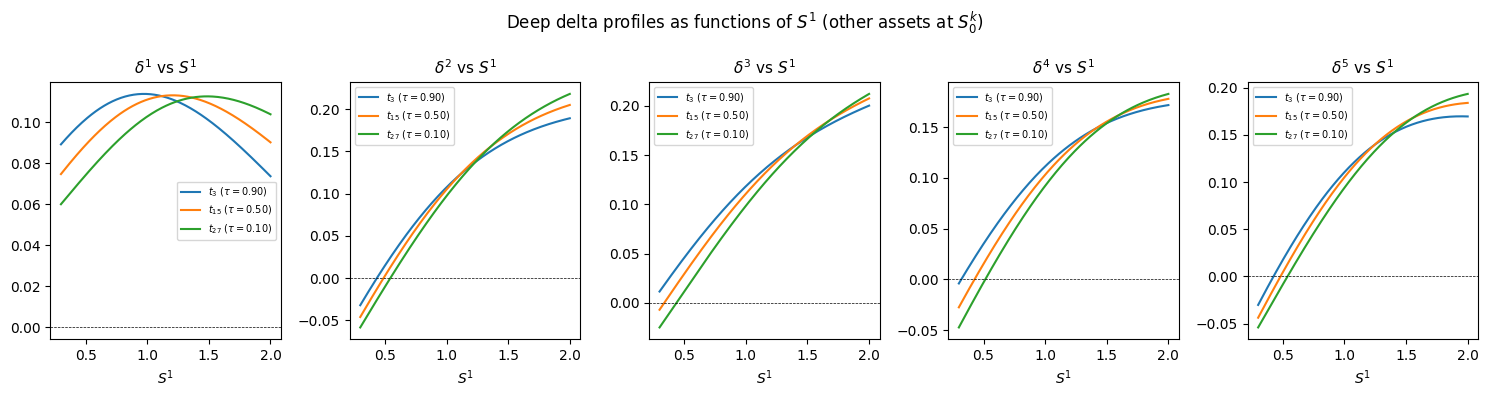

In [13]:
# Delta visualisation: vary S1, fix all others at S0
N_delta = 200
S1_eval = np.linspace(0.3, 2.0, N_delta)
hedge_eval_delta = np.tile(S0_vec, (N_delta, 1)).copy()
hedge_eval_delta[:, 0] = S1_eval

log_incr_zeros = [np.zeros((N_delta, m)) for _ in range(N)]

xtest_delta = (
    [np.tile(S0_vec, (N_delta, 1))]
    + [np.zeros((N_delta, 1))]
    + [hedge_eval_delta]
    + [np.zeros((N_delta, m))]
    + log_incr_zeros
)

output_delta = model_hedge_strat.predict(xtest_delta, verbose=0)  # type: ignore

time_steps = [int(N * 0.1), int(N * 0.5), int(N * 0.9)]  # early, mid, near-expiry (scales with N)
fig, axes = plt.subplots(1, m, figsize=(3 * m, 4))

for asset_k in range(m):
    for l in time_steps:
        delta_k_l = output_delta[:, 1 + l * m + asset_k]  # type: ignore
        tau = T - grid[l]
        axes[asset_k].plot(S1_eval, delta_k_l,
                           label=r"$t_{%d}$ ($\tau=%.2f$)" % (l, tau))
    axes[asset_k].set_title(r"$\delta^{%d}$ vs $S^1$" % (asset_k + 1), fontsize=11)
    axes[asset_k].set_xlabel(r"$S^1$")
    axes[asset_k].axhline(0, linestyle='--', linewidth=0.5, color='k')
    axes[asset_k].legend(loc="best", fontsize=7)

plt.suptitle("Deep delta profiles as functions of $S^1$ (other assets at $S^k_0$)", fontsize=12)
plt.tight_layout()
plt.show()

## Theoretical experiments — effect of correlation $\rho$ on the option price

We sweep over $\rho \in \{0, 0.3, 0.7, 0.95\}$ and retrain a **small model** ($N_{train} = 2 \times 10^4$, 5 epochs) for each value. We compare the learned premium with the closed-form geometric basket price.

In [14]:
rho_values = [0.0, 0.3, 0.7, 0.95]
N_train_small = 10**4  # small training set for the sweep (speed vs accuracy trade-off)
learned_prices  = []
analytic_prices = []

for rho_val in rho_values:
    Sigma_rho = rho_val * np.ones((m, m)) + (1 - rho_val) * np.eye(m)
    L_rho     = np.linalg.cholesky(Sigma_rho)

    # Analytic price
    p_geom, _ = geometric_basket_call_price(S0_vec, sigma_vec, Sigma_rho, r, T)
    analytic_prices.append(p_geom)

    # Build a quick small model (same architecture, new layers)
    sl_rho = []
    for k in range(d):
        if k < d - 1:
            sl_rho.append(Dense(n, activation="tanh",
                                kernel_initializer="glorot_normal",
                                bias_initializer="zeros",
                                name="sr%d_%d" % (int(100*rho_val), k)))
        else:
            sl_rho.append(Dense(m, activation="linear",
                                kernel_initializer="glorot_normal",
                                bias_initializer="zeros",
                                name="sr%d_out" % int(100*rho_val)))

    # Training set
    log_inc_rho = [
        mu_vec * Delta_T + sigma_vec * np.sqrt(Delta_T) * (np.random.normal(0, 1, (N_train_small, m)) @ L_rho.T)
        for _ in range(N)
    ]
    he_rho = np.tile(S0_vec, (N_train_small, 1)).copy()
    he_rho[:, 0] = np.linspace(0.5, 1.5, N_train_small)

    xt_rho = (
        [np.tile(S0_vec, (N_train_small, 1))]
        + [np.zeros((N_train_small, 1))]
        + [he_rho]
        + [np.zeros((N_train_small, m))]
        + log_inc_rho
    )
    yt_rho = np.zeros((N_train_small, 1))

    # Build model
    price_inp = keras.Input(shape=(m,))
    hedge_inp = keras.Input(shape=(1,))
    he_inp    = keras.Input(shape=(m,))
    prem_inp  = keras.Input(shape=(m,))
    inps      = [price_inp, hedge_inp, he_inp, prem_inp]

    prem_rho = Dense(1, activation="linear", trainable=True,
                     kernel_initializer="glorot_normal",
                     bias_initializer="zeros",
                     name="prem_rho%d" % int(100*rho_val))(prem_inp)  # type: ignore

    p_it   = price_inp
    h_it   = hedge_inp
    he_it  = he_inp
    oh     = []

    for j in range(N):
        t_j = tf.constant(grid[j], dtype=tf.float32)
        tv  = Lambda(lambda x, t=t_j: tf.fill([tf.shape(x)[0], 1], t), name="trv_%d_%d" % (int(100*rho_val),j))(p_it)
        tve = Lambda(lambda x, t=t_j: tf.fill([tf.shape(x)[0], 1], t), name="tev_%d_%d" % (int(100*rho_val),j))(he_it)
        ni  = Concatenate(name="ni_%d_%d" % (int(100*rho_val),j))([tv, p_it])
        nie = Concatenate(name="nie_%d_%d" % (int(100*rho_val),j))([tve, he_it])
        st  = ni
        ste = nie
        for layer in sl_rho:
            st  = layer(st)
            ste = layer(ste)

        inc  = keras.Input(shape=(m,), name="inc_%d_%d" % (int(100*rho_val),j))
        inps = inps + [inc]

        lp = Lambda(lambda x: tf.math.log(x), name="lp_%d_%d" % (int(100*rho_val),j))(p_it)
        lp = Add(name="la_%d_%d" % (int(100*rho_val),j))([lp, inc])
        pn = Lambda(lambda x: tf.math.exp(x), name="ep_%d_%d" % (int(100*rho_val),j))(lp)
        pi = Subtract(name="pi_%d_%d" % (int(100*rho_val),j))([pn, p_it])

        pv = Add(name="pv_%d_%d" % (int(100*rho_val),j))([prem_rho, h_it])
        dv = Multiply(name="dv_%d_%d" % (int(100*rho_val),j))([st, p_it])
        ds = Lambda(lambda x: tf.reduce_sum(x, axis=1, keepdims=True), name="ds_%d_%d" % (int(100*rho_val),j))(dv)
        cp = Subtract(name="cp_%d_%d" % (int(100*rho_val),j))([pv, ds])
        it = Lambda(lambda x: r * Delta_T * x, name="it_%d_%d" % (int(100*rho_val),j))(cp)
        dc_v = Multiply(name="dcv_%d_%d" % (int(100*rho_val),j))([st, pi])
        dc   = Lambda(lambda x: tf.reduce_sum(x, axis=1, keepdims=True), name="dc_%d_%d" % (int(100*rho_val),j))(dc_v)
        hn   = Add(name="hn_%d_%d" % (int(100*rho_val),j))([it, dc])
        h_it = Add(name="hh_%d_%d" % (int(100*rho_val),j))([h_it, hn])
        oh   = oh + [ste]
        p_it = pn

    # Geometric basket payoff
    lp_T  = Lambda(lambda x: tf.math.log(x), name="lpT_%d" % int(100*rho_val))(p_it)
    ml    = Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True), name="ml_%d" % int(100*rho_val))(lp_T)
    gb    = Lambda(lambda x: tf.math.exp(x), name="gb_%d" % int(100*rho_val))(ml)
    pay   = Lambda(lambda x: tf.math.maximum(x - 1.0, 0.0), name="pay_%d" % int(100*rho_val))(gb)

    out_m = Add(name="oVT_%d" % int(100*rho_val))([prem_rho, h_it])
    out_m = Subtract(name="oerr_%d" % int(100*rho_val))([out_m, pay])
    out   = [out_m] + oh + [prem_rho]
    out   = Concatenate(name="ocat_%d" % int(100*rho_val))(out)

    mod_rho = keras.models.Model(inputs=inps, outputs=out)
    mod_rho.compile(optimizer="adam", loss=custom_loss)
    mod_rho.fit(x=xt_rho, y=yt_rho, epochs=5, verbose=False, batch_size=256)  # type: ignore

    out_rho = mod_rho.predict(xt_rho, verbose=0)  # type: ignore
    learned_prices.append(float(out_rho[0, -1]))

    print("rho=%.2f  analytic=%.4f  learned=%.4f" % (rho_val, p_geom, float(out_rho[0, -1])))

rho=0.00  analytic=0.0476  learned=0.0476


rho=0.30  analytic=0.0668  learned=0.0664


rho=0.70  analytic=0.0865  learned=0.0865


rho=0.95  analytic=0.0972  learned=0.0966


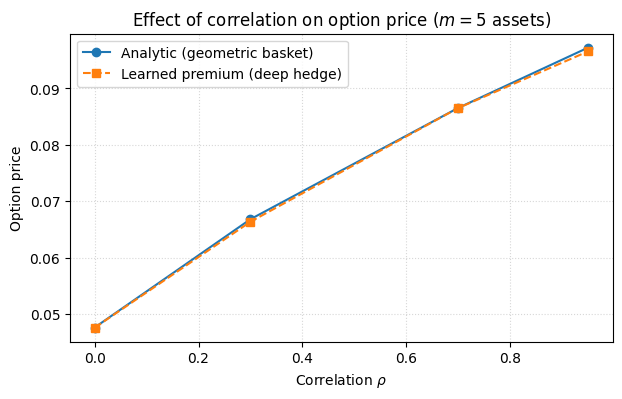

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(rho_values, analytic_prices, 'o-', label="Analytic (geometric basket)")
plt.plot(rho_values, learned_prices,  's--', label="Learned premium (deep hedge)")
plt.xlabel(r"Correlation $\rho$")
plt.ylabel("Option price")
plt.title("Effect of correlation on option price ($m=%d$ assets)" % m, fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

**Commentary on the correlation sweep.**

- The geometric basket call price **increases with $\rho$**: higher correlation means the assets tend to move together, so the geometric mean is more volatile, and the option is worth more.
- The learned premium tracks this trend. For small training budgets (as used here), the learned price may slightly over- or under-shoot the analytic value, but the monotonic relationship with $\rho$ is recovered.
- In the limit $\rho \to 1$, all assets become identical and the price converges to the single-asset BS price. In the limit $\rho \to 0$, diversification reduces the effective volatility and the price decreases.

## Summary, limitations, and outlook

**Advantages of the shared time-input architecture:**
- **Scalability**: the number of parameters grows as $\mathcal{O}((m+1) \cdot n + n^2 \cdot (d-1) + n \cdot m)$, independent of $N$. For $N=100$, $m=5$, $d=4$, $n=64$: approximately 16,000 parameters vs $\sim 1.6 \times 10^6$ for $N$ separate networks.
- **Generalisation**: the network implicitly interpolates the strategy across time, which can be beneficial when the optimal delta is smooth in $t$.

**Limitations:**
- For a large number of assets, the state space is high-dimensional: the network input has dimension $m+1$. With $m = 5$ this is still manageable, but for $m \gtrsim 20$, the curse of dimensionality would require a much larger network or a different approach (e.g. recurrent/transformer architecture).
- The geometric basket payoff is chosen for its closed-form benchmark; more complex payoffs (e.g. best-of, worst-of) would not have an analytical reference and would require Monte Carlo estimation.
- Deep hedging assumes a known model for simulation. In practice, the model must be calibrated to market data, and model risk is an important concern.

**Further extensions:** using the full path history as input (recurrent networks), incorporating transaction costs, or using reinforcement learning to optimise more general risk measures (CVaR, expected shortfall) instead of MSE.